# Tesla Stock Price Prediction

### Objectives

- Analyze Tesla Stock Data
- Build SimpleRNN Model
- Build LSTM Model
- Compare Performance
- Deploy using Streamlit

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [3]:
df = pd.read_csv("../data/TSLA.csv")

In [4]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


## Understand Dataset

In [5]:
df.shape

(2416, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [7]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


## Dataset Overview

The Tesla stock dataset contains historical stock information including Open, High, Low, Close, Adjusted Close, and Volume.

The dataset will be used to analyze stock trends and build deep learning models for stock price prediction.

## Data Cleaning

In [9]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

### Observation

No missing values were found in the dataset.

### Convert Date Column

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2416 non-null   datetime64[ns]
 1   Open       2416 non-null   float64       
 2   High       2416 non-null   float64       
 3   Low        2416 non-null   float64       
 4   Close      2416 non-null   float64       
 5   Adj Close  2416 non-null   float64       
 6   Volume     2416 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 132.3 KB


### Set Date as Index

In [12]:
df.set_index("Date", inplace=True)

In [13]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


## First Visualization

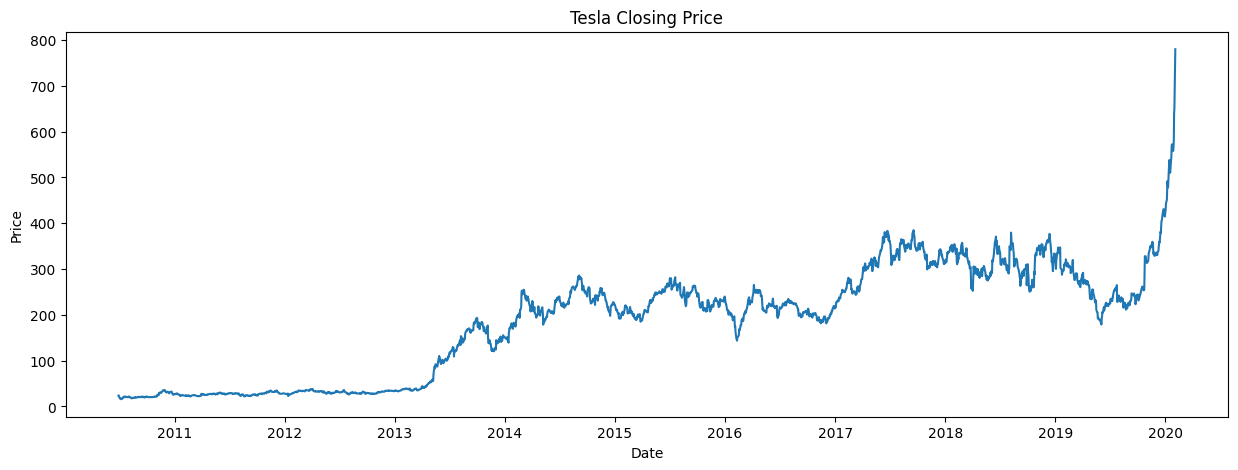

In [14]:
plt.figure(figsize=(15,5))

plt.plot(df["Close"])

plt.title("Tesla Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

### Observation

The closing price of Tesla stock shows significant growth over the years, with periods of volatility and rapid upward movement. This indicates that Tesla stock exhibits strong time-series characteristics suitable for RNN and LSTM modeling.

# Exploratory Data Analysis

### 1. Trading Volume Trend

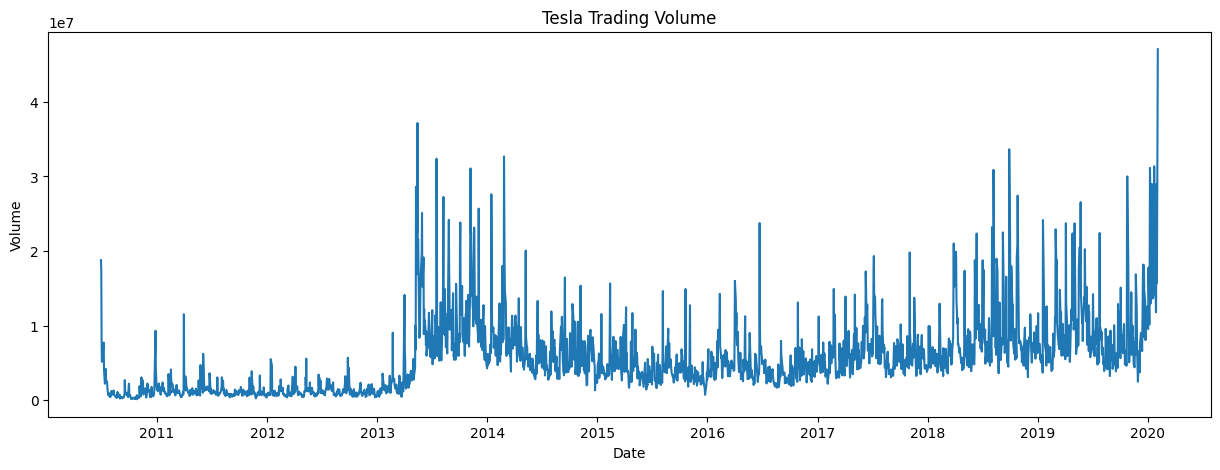

In [15]:
plt.figure(figsize=(15,5))

plt.plot(df['Volume'])

plt.title('Tesla Trading Volume')

plt.xlabel('Date')

plt.ylabel('Volume')

plt.show()

### Observation

Trading volume fluctuates significantly over time, indicating periods of increased market activity and investor interest.

### 2. 50-Day Moving Average

In [16]:
df['MA50'] = df['Close'].rolling(window=50).mean()

### 3. 200-Day Moving Average

In [17]:
df['MA200'] = df['Close'].rolling(window=200).mean()

### Moving Average Analysis

To better understand Tesla's stock price trends, 50-day and 200-day moving averages were calculated. Moving averages help smooth short-term fluctuations and highlight long-term market trends.

### 4. Moving Average Visualization

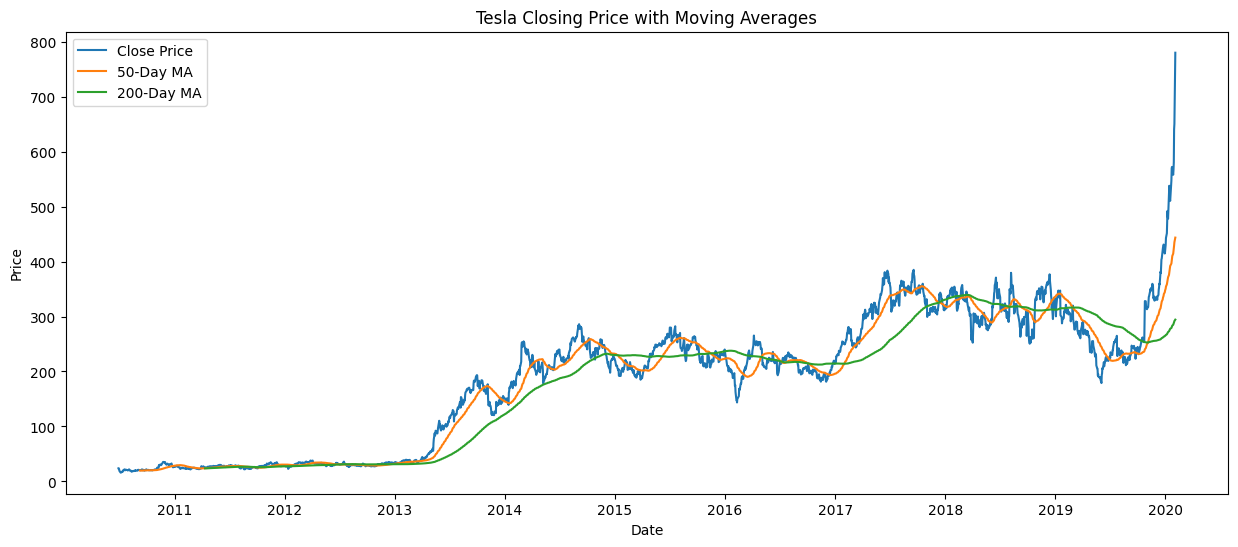

In [18]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'], label='Close Price')

plt.plot(df['MA50'], label='50-Day MA')

plt.plot(df['MA200'], label='200-Day MA')

plt.title('Tesla Closing Price with Moving Averages')

plt.xlabel('Date')

plt.ylabel('Price')

plt.legend()

plt.show()

### Observation

The Tesla closing price shows a clear long-term upward trend with periods of volatility. The 50-day moving average reacts more quickly to short-term price changes, while the 200-day moving average represents the long-term trend. When the 50-day moving average remains above the 200-day moving average, it generally indicates a bullish market trend. The moving averages help smooth out daily price fluctuations and provide a clearer understanding of overall stock performance.

### 5. Daily Return

In [19]:
df['Daily_Return'] = df['Close'].pct_change()

In [20]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA50,MA200,Daily_Return
Date,,,,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,NaN,NaN,NaN
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,NaN,NaN,-0.002511
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,NaN,NaN,-0.078473
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800,NaN,NaN,-0.125683
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900,NaN,NaN,-0.160937


### Daily Return Distribution

Daily returns represent the percentage change in Tesla's closing stock price from one trading day to the next. Analyzing the distribution of daily returns helps understand the stock's volatility, risk, and overall price movement behavior.

### 6. Daily Return Distribution

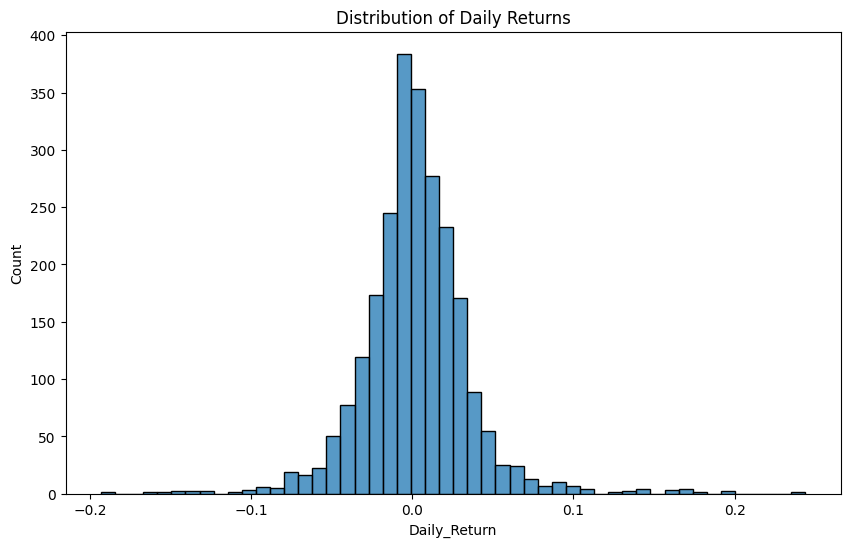

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(df['Daily_Return'].dropna(), bins=50)

plt.title('Distribution of Daily Returns')

plt.show()

### Observation

The distribution of daily returns is concentrated around zero, indicating that most daily price changes are relatively small. However, the presence of values farther from zero suggests occasional significant price movements and market volatility. This behavior is common in stock market data and highlights the importance of using time-series models such as SimpleRNN and LSTM for prediction.

### Correlation Analysis

A correlation heatmap is used to measure the strength and direction of relationships between different stock market features. Correlation values range from -1 to +1, where values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values near 0 indicate little or no relationship.


### 7. Correlation Heatmap


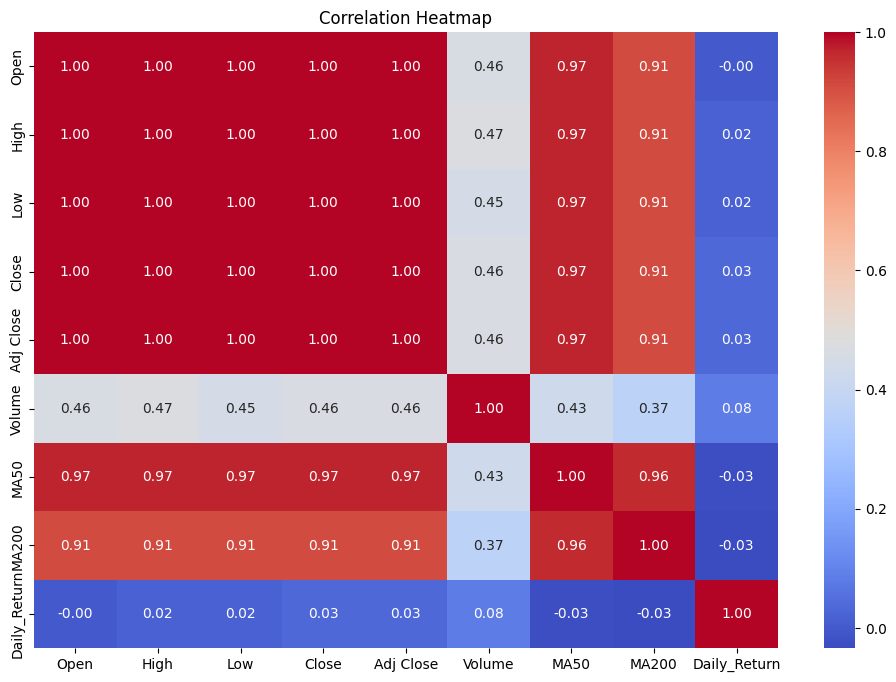

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows a strong positive correlation among the Open, High, Low, Close, and Adjusted Close price variables. This indicates that these stock price features tend to move together. Trading Volume exhibits a relatively weaker correlation with price-related features, suggesting that price movements are not solely dependent on trading volume. The strong relationships among stock price attributes confirm the consistency of the dataset and provide useful insights for predictive modeling.

### 8. Remove Null Values Generated by Moving Average

Because MA50, MA200 and Daily_Return create null values.

In [23]:
df.dropna(inplace=True)

In [24]:
df.isnull().sum()

Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
MA50            0
MA200           0
Daily_Return    0
dtype: int64

# Data Preparation for Deep Learning

### Step 1: Select Target Variable

In [27]:
data = df[['Close']]

In [28]:
data.head()

,Close
Date,
2011-04-12,24.650000
2011-04-13,24.930000
2011-04-14,25.139999
2011-04-15,25.580000
2011-04-18,25.030001


### Step 2: Scale the Data

RNN and LSTM work much better when data is normalized.

In [29]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [30]:
scaled_data[:5]

array([[0.00356177],
       [0.00393114],
       [0.00420816],
       [0.0047886 ],
       [0.00406306]])

### Data Scaling

The Close price values were normalized using MinMaxScaler to improve the convergence and performance of deep learning models. The scaled values range between 0 and 1.

### Step 3: Create Sequences Function

In [31]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(seq_length, len(data)):

        X.append(data[i-seq_length:i])

        y.append(data[i])

    return np.array(X), np.array(y)

### Step 4: Generate Sequences

I will use 60 previous days.

In [32]:
sequence_length = 60

X, y = create_sequences(
    scaled_data,
    sequence_length
)

In [33]:
print("X Shape:", X.shape)

print("y Shape:", y.shape)

X Shape: (2157, 60, 1)
y Shape: (2157, 1)


### Step 6: Train-Test Split

Because this is time-series data, do NOT use train_test_split().

In [34]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [35]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1725, 60, 1)
(432, 60, 1)
(1725, 1)
(432, 1)


# SimpleRNN Model

## Build Model

In [37]:
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(
    SimpleRNN(
        units=50
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

### SimpleRNN Model Architecture

The SimpleRNN model consists of two recurrent neural network layers with 50 units each, followed by dropout layers to reduce overfitting. A dense output layer is used to predict the next closing stock price. The architecture is designed to capture temporal dependencies and patterns in Tesla's historical stock price data.

## Model Summary

In [38]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

### Observation

The model contains two SimpleRNN layers and two Dropout layers, enabling it to learn sequential patterns while reducing the risk of overfitting. The final Dense layer produces a single output corresponding to the predicted stock closing price.

## Compile Model

In [39]:
rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

### Model Training

The SimpleRNN model was trained using the training dataset for 20 epochs with a batch size of 32. The Adam optimizer and Mean Squared Error (MSE) loss function were used during training. Validation data was provided to monitor the model's performance on unseen data and to assess its generalization capability.

## Train Model

In [40]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0375 - val_loss: 0.0039
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0092 - val_loss: 0.0035
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0055 - val_loss: 0.0024
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0042 - val_loss: 0.0023
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0030 - val_loss: 0.0019
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0025 - val_loss: 0.0012
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0022 - val_loss: 0.0013
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0019 - val_loss: 0.0010
Epoch 10/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0017 - val_loss: 8.8640e-04
Epoch 11/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 12/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss:

### Training Observation

The training and validation loss decreased consistently over the epochs, indicating that the model successfully learned the underlying patterns in Tesla's historical stock price data. The close alignment between training and validation loss suggests that the model generalized well without significant overfitting.

### Training and Validation Loss Visualization

The following graph illustrates the training and validation loss across epochs. Monitoring loss trends helps evaluate the learning process and identify potential issues such as overfitting or underfitting.

## Plot Loss

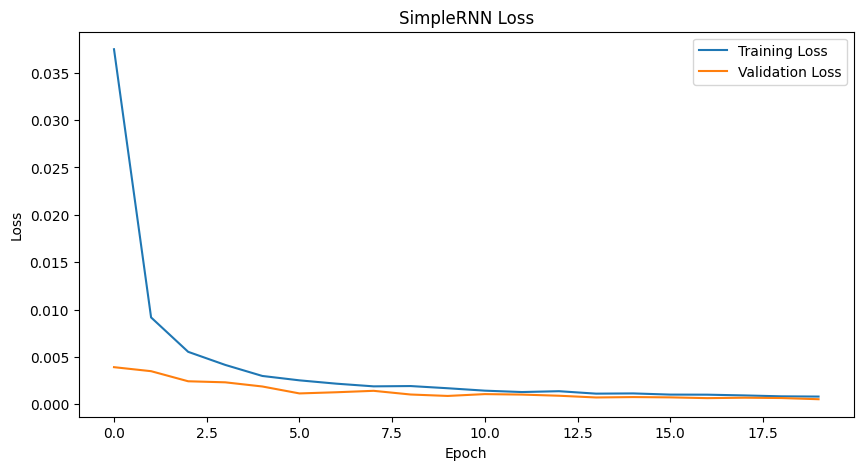

In [41]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'],
         label='Training Loss')

plt.plot(history_rnn.history['val_loss'],
         label='Validation Loss')

plt.title('SimpleRNN Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

### Observation

The training and validation loss curves show a downward trend and remain relatively close to each other throughout the training process. This indicates that the model learned effectively from the training data and maintained good predictive performance on the validation dataset.

# SimpleRNN Prediction and Evaluation
 # Step 1: Make Predictions

In [42]:
rnn_predictions = rnn_model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


# Step 2: Convert Back To Original Prices

Currently predictions are scaled.

In [43]:
rnn_predictions = scaler.inverse_transform(rnn_predictions)

y_test_actual = scaler.inverse_transform(y_test)

# Step 3: Evaluate Model

In [44]:
rnn_mse = mean_squared_error(
    y_test_actual,
    rnn_predictions
)

rnn_rmse = np.sqrt(rnn_mse)

rnn_mae = mean_absolute_error(
    y_test_actual,
    rnn_predictions
)

rnn_r2 = r2_score(
    y_test_actual,
    rnn_predictions
)

print("MSE :", rnn_mse)
print("RMSE:", rnn_rmse)
print("MAE :", rnn_mae)
print("R2  :", rnn_r2)

MSE : 310.290478448148
RMSE: 17.615063963782475
MAE : 11.342351664998374
R2  : 0.945848887393836


### SimpleRNN Evaluation

The SimpleRNN model achieved strong predictive performance with an R² score of 0.9458, indicating that the model explained approximately 94.58% of the variation in Tesla's stock prices. The low RMSE and MAE values demonstrate that the model effectively captured historical stock price patterns and trends.

### Performance Summary

The SimpleRNN model achieved strong predictive performance with:

- MSE: 310.29
- RMSE: 17.62
- MAE: 11.34
- R² Score: 0.9458

The high R² score indicates that the model explains approximately 94.58% of the variance in Tesla's stock prices, demonstrating good forecasting capability.

# Step 4: Actual vs Predicted Graph

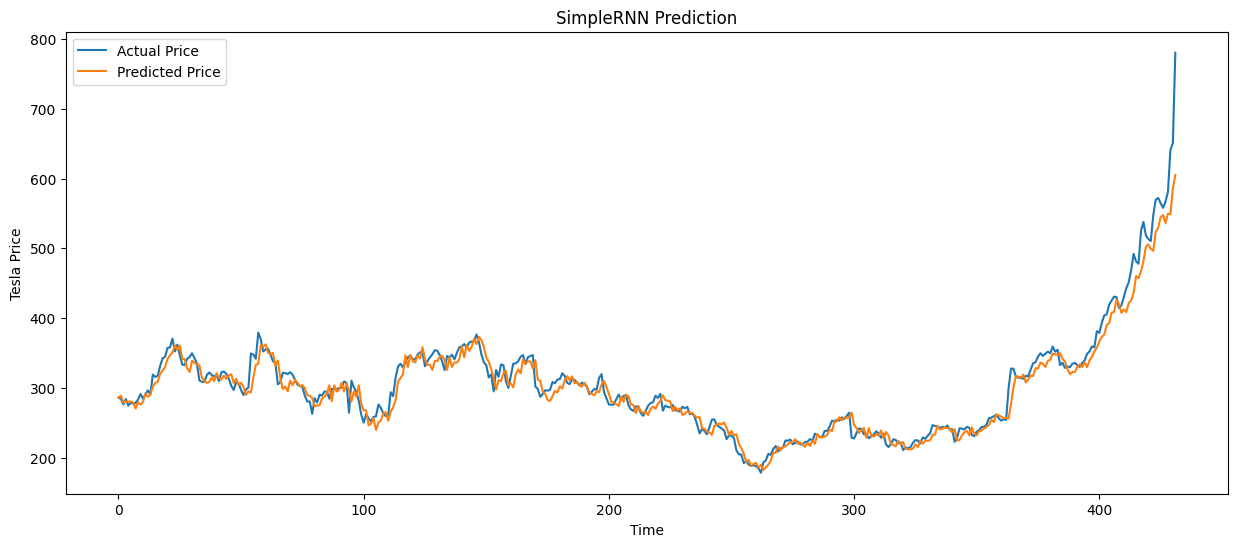

In [45]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    rnn_predictions,
    label='Predicted Price'
)

plt.title('SimpleRNN Prediction')

plt.xlabel('Time')

plt.ylabel('Tesla Price')

plt.legend()

plt.show()

### Observation

The SimpleRNN model's predicted stock prices closely follow the actual Tesla stock prices. The model successfully captures the overall trend and movement of the stock market data, with only minor deviations during periods of rapid price fluctuations. This indicates that the model has learned the temporal patterns present in the historical closing prices and can effectively predict future stock price behavior.

# Step 5: Save Model

Create model file for Streamlit.

In [46]:
rnn_model.save(
    "../models/rnn_model.h5"
)

### SimpleRNN Observation

The SimpleRNN model successfully captured Tesla stock price trends and achieved low training and validation loss. The model demonstrated the ability to learn temporal dependencies from historical closing prices.

# LSTM Model  

Long Short-Term Memory (LSTM) networks are an advanced type of recurrent neural network designed to learn long-term dependencies in sequential data. LSTM models are particularly effective for time-series forecasting because they can retain important information over extended periods while mitigating the vanishing gradient problem.

### Step 1: Build LSTM Model

In [47]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(
    LSTM(
        units=50
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

### LSTM Model Architecture

The LSTM model consists of two stacked LSTM layers with 50 units each, followed by dropout layers to reduce overfitting. The final dense layer outputs the predicted closing stock price.

### Step 2: Model Summary

In [48]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

### Observation

The model contains two LSTM layers and two dropout layers. LSTM networks are capable of learning both short-term and long-term dependencies in stock price sequences, making them well-suited for financial time-series forecasting.

### Model Compilation

The LSTM model is compiled using the Adam optimizer and Mean Squared Error (MSE) loss function. Adam provides efficient gradient-based optimization, while MSE measures prediction error during training.

### Step 3: Compile Model

In [49]:
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

### Model Training

The LSTM model is trained for 20 epochs with a batch size of 32. Validation data is used to monitor performance on unseen data during training.

### Step 4: Train Model

In [50]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0040 - val_loss: 0.0016
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 8.1736e-04 - val_loss: 0.0016
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 7.8782e-04 - val_loss: 0.0015
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 8.3236e-04 - val_loss: 0.0017
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 7.3970e-04 - val_loss: 0.0015
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 6.5544e-04 - val_loss: 0.0016
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 6.4105e-04 - val_loss: 0.0016
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 6.5827e-04 - val_loss: 0.0021
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 6.6330e-04 - val_loss: 0.0015
Epoch 10/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 5.5444e-04 - val_loss: 0.0016
Epoch 11/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 5.7526e-04 - val_loss: 0.0012
Epoch 12/20
54/54 ━━━━

### Training Observation

The LSTM model demonstrated stable learning throughout the training process. Both training loss and validation loss decreased consistently across epochs, indicating successful learning of temporal patterns in Tesla's stock price data. The final validation loss was lower than that achieved by the SimpleRNN model, suggesting that the LSTM architecture may provide improved forecasting performance by capturing long-term dependencies more effectively.

### Training and Validation Loss Visualization

The following graph illustrates the variation of training loss and validation loss across training epochs. Monitoring these curves helps evaluate the learning behavior and generalization capability of the model.

### Loss Graph

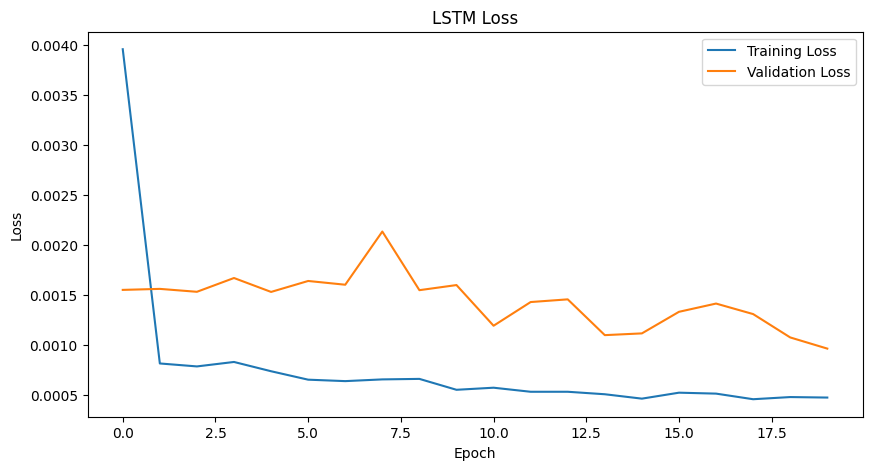

In [51]:
plt.figure(figsize=(10,5))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

### Observation

The training and validation loss curves show a decreasing trend and remain relatively close throughout the training process. This indicates that the model learned effectively from the training data while maintaining good performance on unseen data. No significant signs of overfitting were observed.

# LSTM Evaluation

### Step 1: Predictions

In [52]:
lstm_predictions = lstm_model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step


### Step 2: Convert Back to Original Prices

In [53]:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

y_test_actual = scaler.inverse_transform(
    y_test
)

## LSTM Evaluation Metrics

### Step 3: Evaluation Metrics

In [54]:
lstm_mse = mean_squared_error(
    y_test_actual,
    lstm_predictions
)

lstm_rmse = np.sqrt(lstm_mse)

lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions
)

lstm_r2 = r2_score(
    y_test_actual,
    lstm_predictions
)

print("MSE :", lstm_mse)
print("RMSE:", lstm_rmse)
print("MAE :", lstm_mae)
print("R2  :", lstm_r2)

MSE : 554.9529504987668
RMSE: 23.55743938756432
MAE : 16.032440255210595
R2  : 0.9031510091322267


### LSTM Evaluation

The LSTM model was evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R² Score. These metrics provide insight into the model's prediction accuracy and forecasting capability on unseen stock price data.

### Actual vs Predicted Stock Prices

The following graph compares the actual Tesla stock prices with the prices predicted by the LSTM model.

### Step 4: Actual vs Predicted Graph

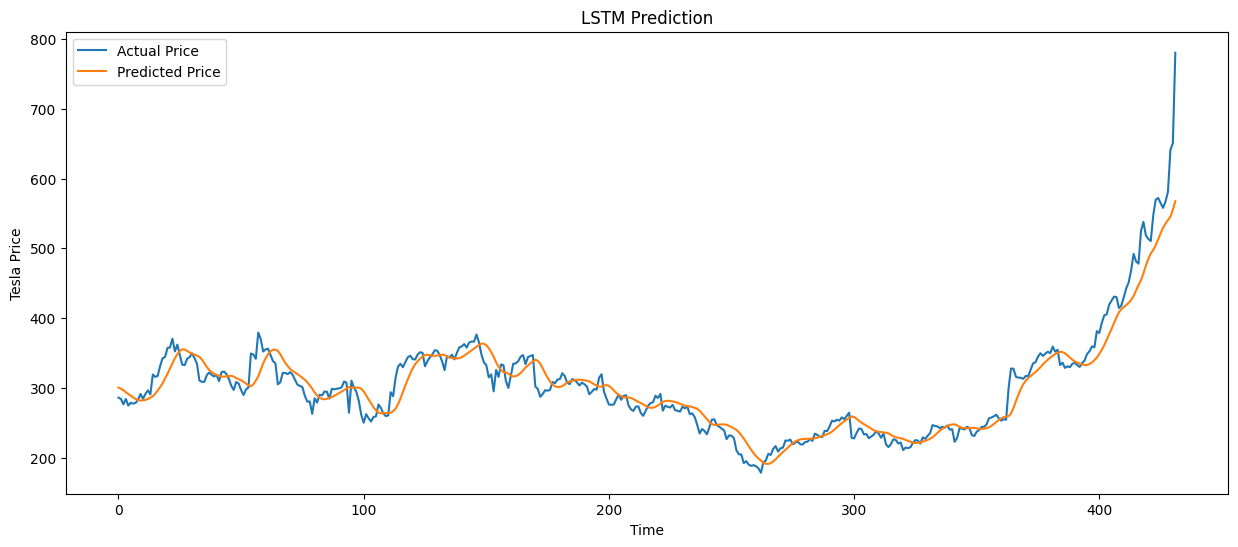

In [55]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    lstm_predictions,
    label='Predicted Price'
)

plt.title('LSTM Prediction')

plt.xlabel('Time')

plt.ylabel('Tesla Price')

plt.legend()

plt.show()

### Observation

The LSTM model predictions closely follow the actual Tesla stock prices, indicating that the model successfully captured both short-term and long-term temporal patterns. The close alignment between actual and predicted values demonstrates the effectiveness of LSTM networks for stock price forecasting.

### Step 6: Save Model

In [56]:
lstm_model.save(
    "../models/lstm_model.h5"
)

# Model Comparison

The performance of both SimpleRNN and LSTM models was compared using multiple evaluation metrics to determine the most suitable model for Tesla stock price prediction.

In [57]:
comparison_df = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R² Score"],
    "SimpleRNN": [
        rnn_mse,
        rnn_rmse,
        rnn_mae,
        rnn_r2
    ],
    "LSTM": [
        lstm_mse,
        lstm_rmse,
        lstm_mae,
        lstm_r2
    ]
})

comparison_df

,Metric,SimpleRNN,LSTM
0,MSE,310.290478,554.952950
1,RMSE,17.615064,23.557439
2,MAE,11.342352,16.032440
3,R² Score,0.945849,0.903151


### Observation

The SimpleRNN model achieved better performance than the LSTM model across all evaluation metrics. It produced lower prediction errors and a higher R² score, indicating superior forecasting capability for this dataset. Based on the experimental results, SimpleRNN was selected as the best-performing model for Tesla stock price prediction.